# **1 Million Brain Cells**
**Author:** [Haihui Zhang](https://github.com/haihuilab/scbiot)
**Copyright:** [scbiot](https://scbiot.readthedocs.io/en/stable/)

This notebook was modified from [here] (https://rapids-singlecell.readthedocs.io/en/latest/notebooks/demo_gpu-seuratv3-brain-1M.html) with rapids-singlecell

In [1]:
import scanpy as sc
import anndata as ad
import cupy as cp
import numpy as np

import time
from pathlib import Path
import rapids_singlecell as rsc

import scbiot as scb

import gc
import warnings

warnings.filterwarnings("ignore")

dir = Path.cwd()
print(dir)

sc.logging.print_header()

/home/figo/miniconda3/envs/rapidgenomics/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scbiot version 1.1.2


2025-12-02 21:21:57 | [INFO] Loading faiss with AVX512 support.
2025-12-02 21:21:57 | [INFO] Could not load library with AVX512 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx512'")
2025-12-02 21:21:57 | [INFO] Loading faiss with AVX2 support.
2025-12-02 21:21:57 | [INFO] Could not load library with AVX2 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx2'")
2025-12-02 21:21:57 | [INFO] Loading faiss.
2025-12-02 21:21:57 | [INFO] Successfully loaded faiss.


/home/figo/software/python_libs/scbiot/examples


Package,Version
scanpy,1.11.5
anndata,0.12.6
cupy,13.6.0
numpy,2.2.6
rapids_singlecell,0.13.4
scbiot,1.1.2
Component,Info
Python,"3.13.9 | packaged by conda-forge | (main, Oct 22 2025, 23:33:35) [GCC 14.3.0]"
OS,Linux-6.11.0-29-generic-x86_64-with-glibc2.39
CPU,"64 logical CPU cores, x86_64"


## Load and Prepare Data

We load the sparse count matrix from an `h5ad` file using Scanpy. The sparse count matrix will then be placed on the GPU. 

In [7]:
data_load_start = time.time()

In [8]:
h5_path = f"{dir}/inputs/1M_neurons_filtered_gene_bc_matrices_h5.h5"

adata = sc.read_10x_h5(
    h5_path,
    backup_url='https://s3-us-west-2.amazonaws.com/10x.files/samples/cell/1M_neurons/1M_neurons_filtered_gene_bc_matrices_h5.h5',
)
adata.var_names_make_unique()

In [9]:
# marker genes
MITO_GENE_PREFIX = "mt-" # Prefix for mitochondrial genes to regress out
markers = ["Stmn2", "Hes1", "Olig1"] # Marker genes for visualization

# filtering cells
min_genes_per_cell = 200 # Filter out cells with fewer genes than this expressed 
max_genes_per_cell = 6000 # Filter out cells with more genes than this expressed 

# filtering genes
min_cells_per_gene = 1 # Filter out genes expressed in fewer cells than this
n_top_genes = 4000 # Number of highly variable genes to retain

# PCA
n_components = 100 # Number of principal components to compute

# KNN
n_neighbors = 15 # Number of nearest neighbors for KNN graph
knn_n_pcs = 50 # Number of principal components to use for finding nearest neighbors

# UMAP
umap_min_dist = 0.3 
umap_spread = 1.0

# Gene ranking
ranking_n_top_genes = 50 # Number of differential genes to compute for each cluster

In [10]:
start = time.time()

Verify the shape of the resulting sparse matrix:

In [11]:
adata.shape

(1306127, 27998)

## Preprocessing

In [12]:
preprocess_start = time.time()

### Create batch labels

In [13]:
# Parse suffix after the last '-'
suffix = adata.obs_names.str.rsplit('-', n=1).str[1]

# Store as categorical to save memory
adata.obs["batch"] = suffix.astype("category")

adata.obs["batch"].head()

AAACCTGAGATAGGAG-1    1
AAACCTGAGCGGCTTC-1    1
AAACCTGAGGAATCGC-1    1
AAACCTGAGGACACCA-1    1
AAACCTGAGGCCCGTT-1    1
Name: batch, dtype: category
Categories (133, object): ['1', '10', '100', '101', ..., '96', '97', '98', '99']

### Quality Control

We perform a basic qulitiy control and plot the results

In [14]:
%%time
sc.pp.filter_cells(adata, min_genes=min_genes_per_cell)
sc.pp.filter_cells(adata, max_genes=max_genes_per_cell)

CPU times: user 33.7 s, sys: 10.3 s, total: 44.1 s
Wall time: 44.1 s


In [15]:
%%time
sc.pp.filter_genes(adata, min_cells=min_cells_per_gene)

CPU times: user 19.8 s, sys: 4.73 s, total: 24.5 s
Wall time: 24.6 s


In [16]:
%%time
mito_genes = adata.var_names.str.startswith(MITO_GENE_PREFIX)
n_counts = np.array(adata.X.sum(axis=1))
adata.obs['percent_mito'] = np.array(np.sum(adata[:, mito_genes].X, axis=1)) / n_counts
adata.obs['n_counts'] = n_counts

CPU times: user 3.55 s, sys: 39 μs, total: 3.55 s
Wall time: 3.55 s


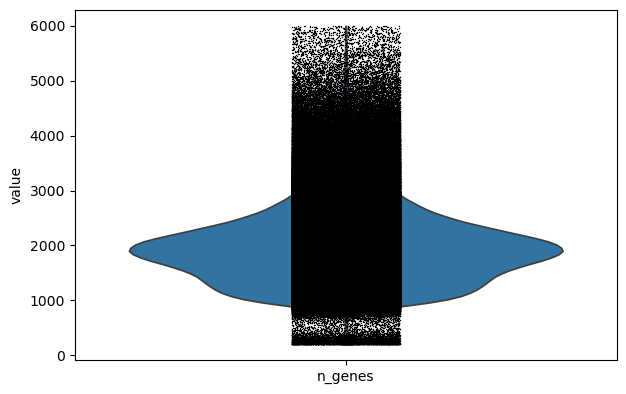

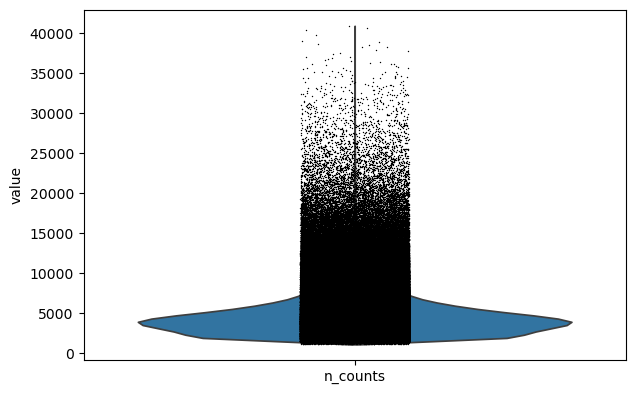

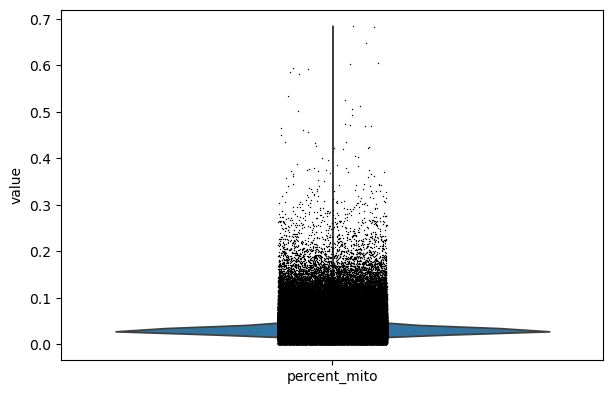

CPU times: user 30.3 s, sys: 7.03 ms, total: 30.3 s
Wall time: 10.3 s


In [17]:
%%time
sc.pl.violin(adata, keys="n_genes")
sc.pl.violin(adata, keys="n_counts")
sc.pl.violin(adata, keys="percent_mito")

### Normalize, Scale, and select Most Variable Genes

In [18]:
%%time
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes, flavor = "cell_ranger")

# Retain marker gene expression
for marker in markers:
    adata.obs[marker + "_raw"] = adata.X[:, adata.var.index == marker].toarray().ravel()

# Filter matrix to only variable genes
adata = adata[:, adata.var.highly_variable]

CPU times: user 37.6 s, sys: 1.17 s, total: 38.8 s
Wall time: 12.6 s


In [19]:
%%time
gc.collect()

CPU times: user 193 ms, sys: 119 μs, total: 193 ms
Wall time: 192 ms


5571

### Regress out confounding factors (number of counts, mitochondrial gene expression)

In [20]:
%%time
sc.pp.regress_out(adata, ['n_counts', 'percent_mito'])

CPU times: user 2min 22s, sys: 2min 6s, total: 4min 28s
Wall time: 13.2 s


In [21]:
adata.shape

(1291337, 4000)

### Scale

In [22]:
%%time
sc.pp.scale(adata, max_value=10)

CPU times: user 29.7 s, sys: 970 ms, total: 30.6 s
Wall time: 11.5 s


### Principal component analysis

We use PCA to reduce the dimensionality of the matrix to its top 100 principal components. 

In [23]:
%%time
sc.tl.pca(adata, n_comps=n_components)

CPU times: user 2h 12min 4s, sys: 14.9 s, total: 2h 12min 19s
Wall time: 2min 44s


We can use scanpy `pca_variance_ratio` plot to inspect the contribution of single PCs to the total variance in the data.

In [24]:
# sc.pl.pca_variance_ratio(adata, log=True, n_pcs=100)

### Run OT

In [29]:
adata, metrics = scb.ot.integrate(adata, modality='rna', obsm_key='X_pca', batch_key='batch', out_key='X_ot')
print(metrics)

[baseline] KNN backend=FAISS-GPU mix=3.1373 strain=0.00000
[iter 01] mix=3.163 overlap0=0.909 strain=0.00060 floor~0.600 J=0.166 best_it=1
[iter 02] mix=3.187 overlap0=0.831 strain=0.00229 floor~0.607 J=0.178 best_it=2
[iter 03] mix=3.204 overlap0=0.760 strain=0.00515 floor~0.614 J=0.182 best_it=3
[iter 04] mix=3.215 overlap0=0.689 strain=0.00925 floor~0.621 J=0.175 best_it=3
[iter 05] mix=3.216 overlap0=0.685 strain=0.00919 floor~0.629 J=0.173 best_it=3
[iter 06] mix=3.217 overlap0=0.687 strain=0.00919 floor~0.636 J=0.175 best_it=3
[early stop] plateau reached.
[final] it*=3 mix=3.204 overlap0=0.760 strain=0.00515 tw=0.998
{'mix': 3.2043035046219, 'overlap0': 0.7596200108528137, 'strain': 0.005152259953320026, 'tw': 0.9975434453724452, 'it': 3}


In [ ]:
adata.write(f"{dir}/inputs/brain_1M.h5ad", compression="lzf")


In [ ]:
adata = sc.read(f"{dir}/inputs/brain_1M.h5ad")

In [3]:
X_ot = np.asarray(adata.obsm["X_ot"], dtype="float32")  # (1291337, 100)

# 2) Build a new AnnData with PCs as X
adata_ot = ad.AnnData(
    X=X_ot,
    obs=adata.obs.copy(),   # keep all metadata (batch, cell_type, etc.)
)

# Give the PCs names, optional but nice
adata_ot.var_names = [f"OT{i+1}" for i in range(X_ot.shape[1])]

adata_ot.obsm["X_ot"] = X_ot


We now load the the AnnData object into VRAM.

### Calculate pseudo labels for tracking model performance. Here we begin to use GPU to speed it up

In [4]:
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

rmm.reinitialize(
    managed_memory=False,  # Allows oversubscription
    pool_allocator=False,  # default is False
    devices=0,  # GPU device IDs to register. By default registers only GPU 0.
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [5]:
%%time
rsc.get.anndata_to_GPU(adata_ot)

CPU times: user 51.6 ms, sys: 236 ms, total: 288 ms
Wall time: 284 ms


In [6]:
# 1. Compute neighbors using Harmony-corrected PCA
rsc.pp.neighbors(adata_ot, use_rep='X_ot')

# 2. Run UMAP 
rsc.tl.umap(adata_ot)

# 3. Leiden clustering
rsc.tl.leiden(adata_ot, resolution=0.8, key_added='leiden_X_ot')
adata_ot

AnnData object with n_obs × n_vars = 1291337 × 100
    obs: 'batch', 'n_genes', 'percent_mito', 'n_counts', 'Stmn2_raw', 'Hes1_raw', 'Olig1_raw', 'leiden_X_ot'
    uns: 'neighbors', 'umap', 'leiden_X_ot'
    obsm: 'X_ot', 'X_umap'
    obsp: 'distances', 'connectivities'

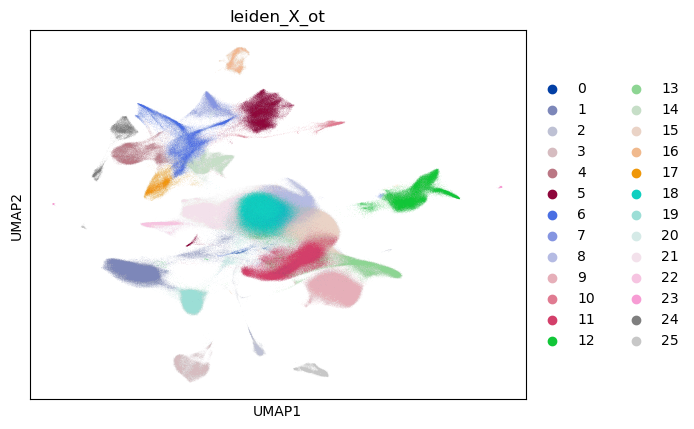

CPU times: user 3.27 s, sys: 36.7 ms, total: 3.31 s
Wall time: 3.26 s


In [ ]:
%%time
sc.pl.umap(
    adata_ot,
    color=['leiden_X_ot'],
    ncols=1
)

### Train the cells with Transformer-VAE model in scBIOT

In [7]:
scb.pp.setup_anndata(adata_ot, var_key='X_ot', batch_key='batch', pseudo_key='leiden_X_ot')

{'var_key': 'X_ot',
 'batch_key': 'batch',
 'pseudo_key': 'leiden_X_ot',
 'true_key': None}

In [ ]:
model = scb.models.vae(adata_ot, verbose=True, batch_size=1024)

Random seed set as 42
[Explicit labels] has_pseudo=True
[Explicit labels] batch_train/test: torch.Size([1162203]) / torch.Size([129134])
[Explicit labels] pseudo_train/test: torch.Size([1162203]) / torch.Size([129134])


In [ ]:
model.train()

### Get latent embeddings

In [ ]:
SCBIOT_LATENT_KEY = "scBIOT"
adata_ot.obsm[SCBIOT_LATENT_KEY] = model.get_latent_representation(n_components=n_components, svd_solver='arpack', random_state=42)
adata.obsm[SCBIOT_LATENT_KEY] = model.get_latent_representation(n_components=n_components, svd_solver='arpack', random_state=42)

In [ ]:
methods = ["X_ot", "scBIOT"] # , "scBIOT_OT"
leiden_methods = [f'{method}_leiden' for method in methods]

for method, leiden_method in zip(methods, leiden_methods):
    rsc.pp.neighbors(adata_ot, use_rep=method)
    rsc.tl.umap(adata_ot)
    adata_ot.obsm[f"X_umap_{method}"] = adata.obsm["X_umap"].copy()
    rsc.tl.leiden(adata_ot, key_added=leiden_method, resolution=0.8)

[W] [17:15:19.868684] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...
CPU times: user 22.4 s, sys: 9.33 s, total: 31.8 s
Wall time: 31.8 s


In [ ]:
import matplotlib.pyplot as plt
import scanpy as sc


# 2 rows x len(methods) columns
fig, axes = plt.subplots(
    2,
    len(methods),
    figsize=(4 * len(methods), 8),
    squeeze=False  # ensures axes is a 2D array
)

for col, method in enumerate(methods):
    # 1) Top row (row=0): color by "batch"
    sc.pl.embedding(
        adata_ot,
        basis=f"X_umap_{method}",  # The coordinates stored in adata.obsm["X_umap_{method}"]
        color="batch",            # Assume adata.obs["batch"] exists
        frameon=False,
        ax=axes[0, col],
        show=False,
        legend_loc="on data",
        legend_fontsize=10,  # smaller font
        title=f"{method}"
    )

    # 2) Bottom row (row=1): color by the Leiden clusters for this method
    leiden_key = f"{method}_leiden"
    sc.pl.embedding(
        adata_ot,
        basis=f"X_umap_{method}",
        color=leiden_key,         # Column in adata.obs
        frameon=False,
        ax=axes[1, col],
        show=False,
        legend_loc="on data",
        legend_fontsize=10,  # smaller font
        # title=f"{method}"
    )

plt.tight_layout()
# fig.savefig("batch_and_leiden_per_embedding.pdf", dpi=300)
# plt.close(fig)
